<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Machine Learning Project 1</font></h1>
<h4 align="center">April 28-2026<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import statistics as st
import seaborn as sns
import matplotlib.pyplot as plt

# from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn import metrics

<div class="alert alert-danger" role="alert"> 
💾 Read CSV file

In [2]:
df = pd.read_excel('california_housing.xlsx')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  int64  
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  int64  
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.4 MB


In [4]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


<div class="alert alert-danger" role="alert"> 
🔎 1. Exploratory Data Analysis (EDA) and Visualization (10%)

C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `

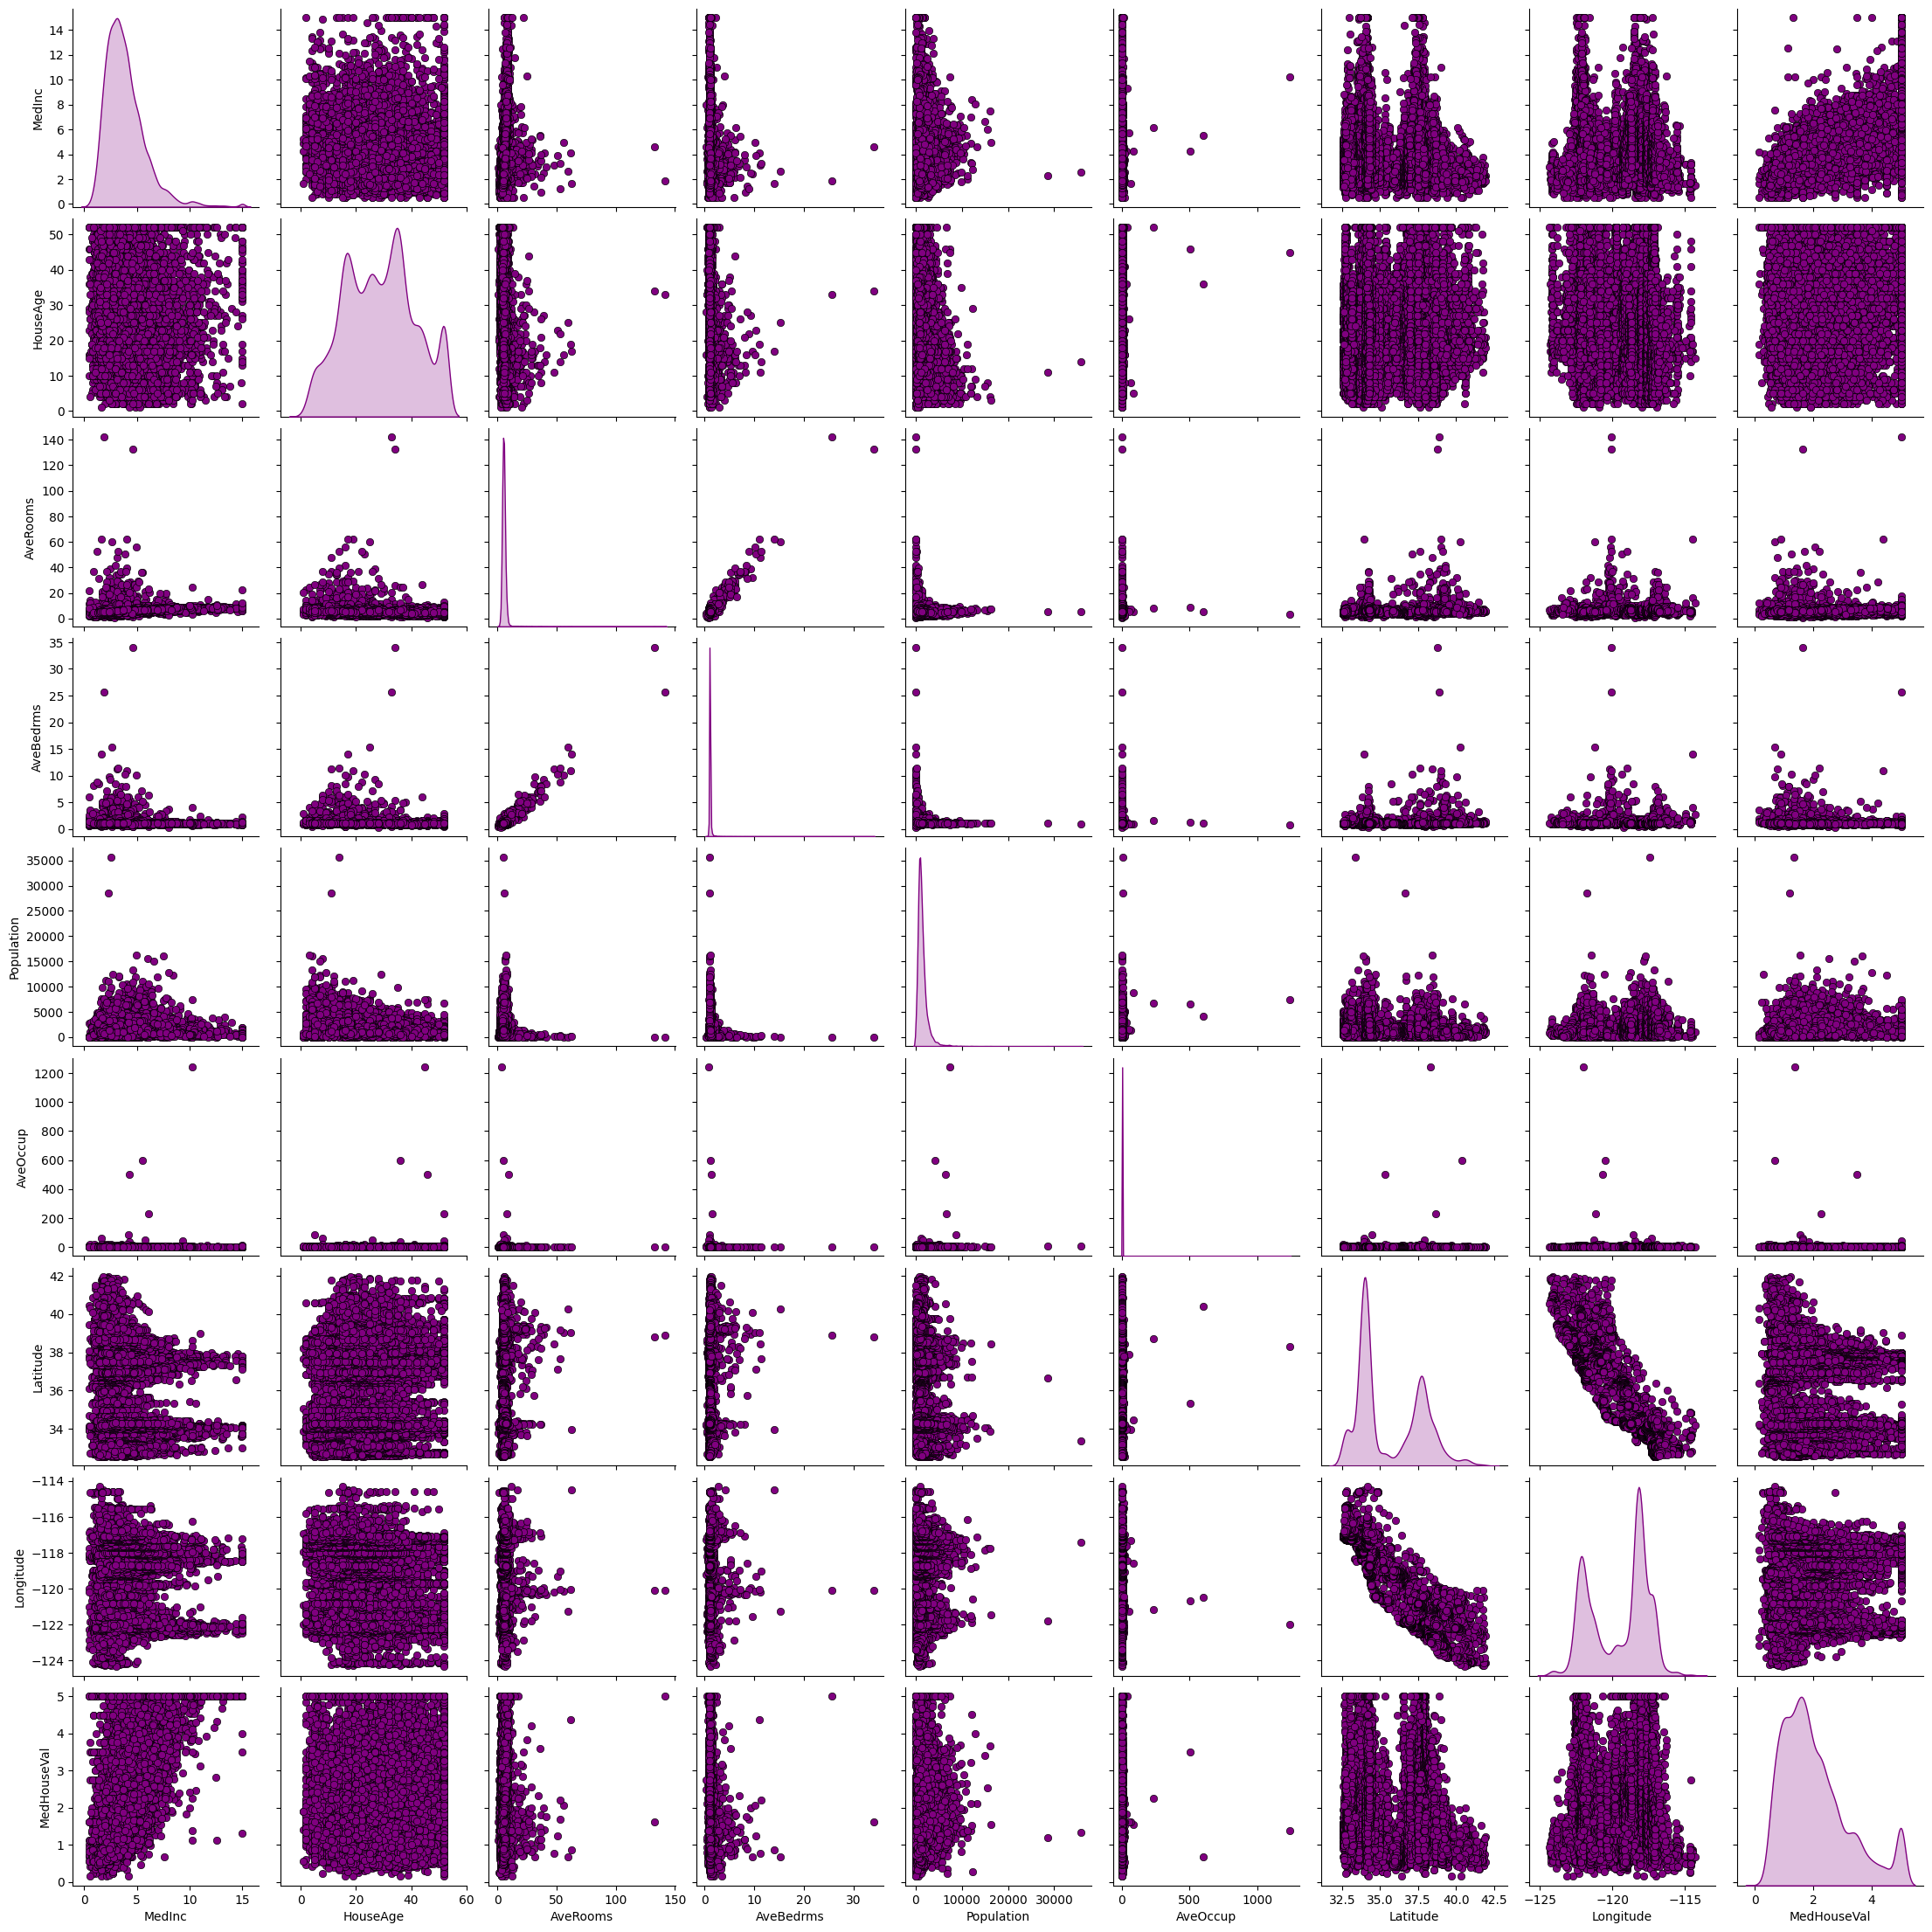

In [5]:
sns.pairplot(
    data=df,
    diag_kind='kde',
    plot_kws={'color':'purple','edgecolor':'black'},
    diag_kws={'color':'purple', 'shade':True}
)
plt.show()

* **Display summary statistics (mean, std, min, max, etc.) for each feature and the target.**

In [6]:
def safe_mode(x):
    try:
        return st.mode(x)
    except:
        return "Multiple"

stats_df = pd.DataFrame(index=df.columns)


stats_df['mean'] = df.mean()
stats_df['std'] = df.std()
stats_df['min'] = df.min()
stats_df['25%'] = df.quantile(0.25)
stats_df['50% (median)'] = df.median()
stats_df['75%'] = df.quantile(0.75)
stats_df['max'] = df.max()
stats_df['mode'] = df.apply(safe_mode)
stats_df['variance'] = df.var()
stats_df['skewness'] = df.skew()
stats_df['kurtosis'] = df.kurtosis()


stats_df

,mean,std,min,25%,50% (median),75%,max,mode,variance,skewness,kurtosis
MedInc,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100,3.12500,3.609323e+00,1.646657,4.952524
HouseAge,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000,52.00000,1.583963e+02,0.060331,-0.800629
AveRooms,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091,5.00000,6.121533e+00,20.697869,879.353264
AveBedrms,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667,1.00000,2.245915e-01,31.316956,1636.711972
Population,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000,891.00000,1.282470e+06,4.935858,73.553116
AveOccup,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333,3.00000,1.078700e+02,97.639561,10651.010636
Latitude,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000,34.06000,4.562293e+00,0.465953,-1.117760
Longitude,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000,-118.31000,4.014139e+00,-0.297801,-1.330152
MedHouseVal,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010,5.00001,1.331615e+00,0.977763,0.327870


* **Create a correlation heatmap to identify relationships among features and with the target.**

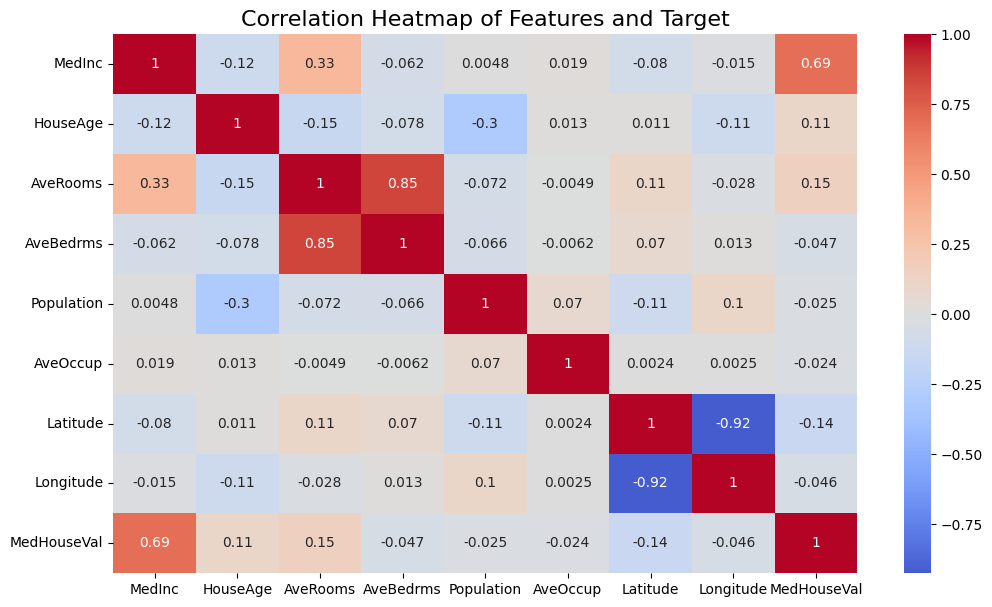

In [7]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    center=0,
    # cmap=plt.cm.rainbow,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Features and Target", fontsize=16, color='black')
plt.show()

* **Plot histograms or boxplots to examine feature distributions and potential outliers.**

* **a) histograms**

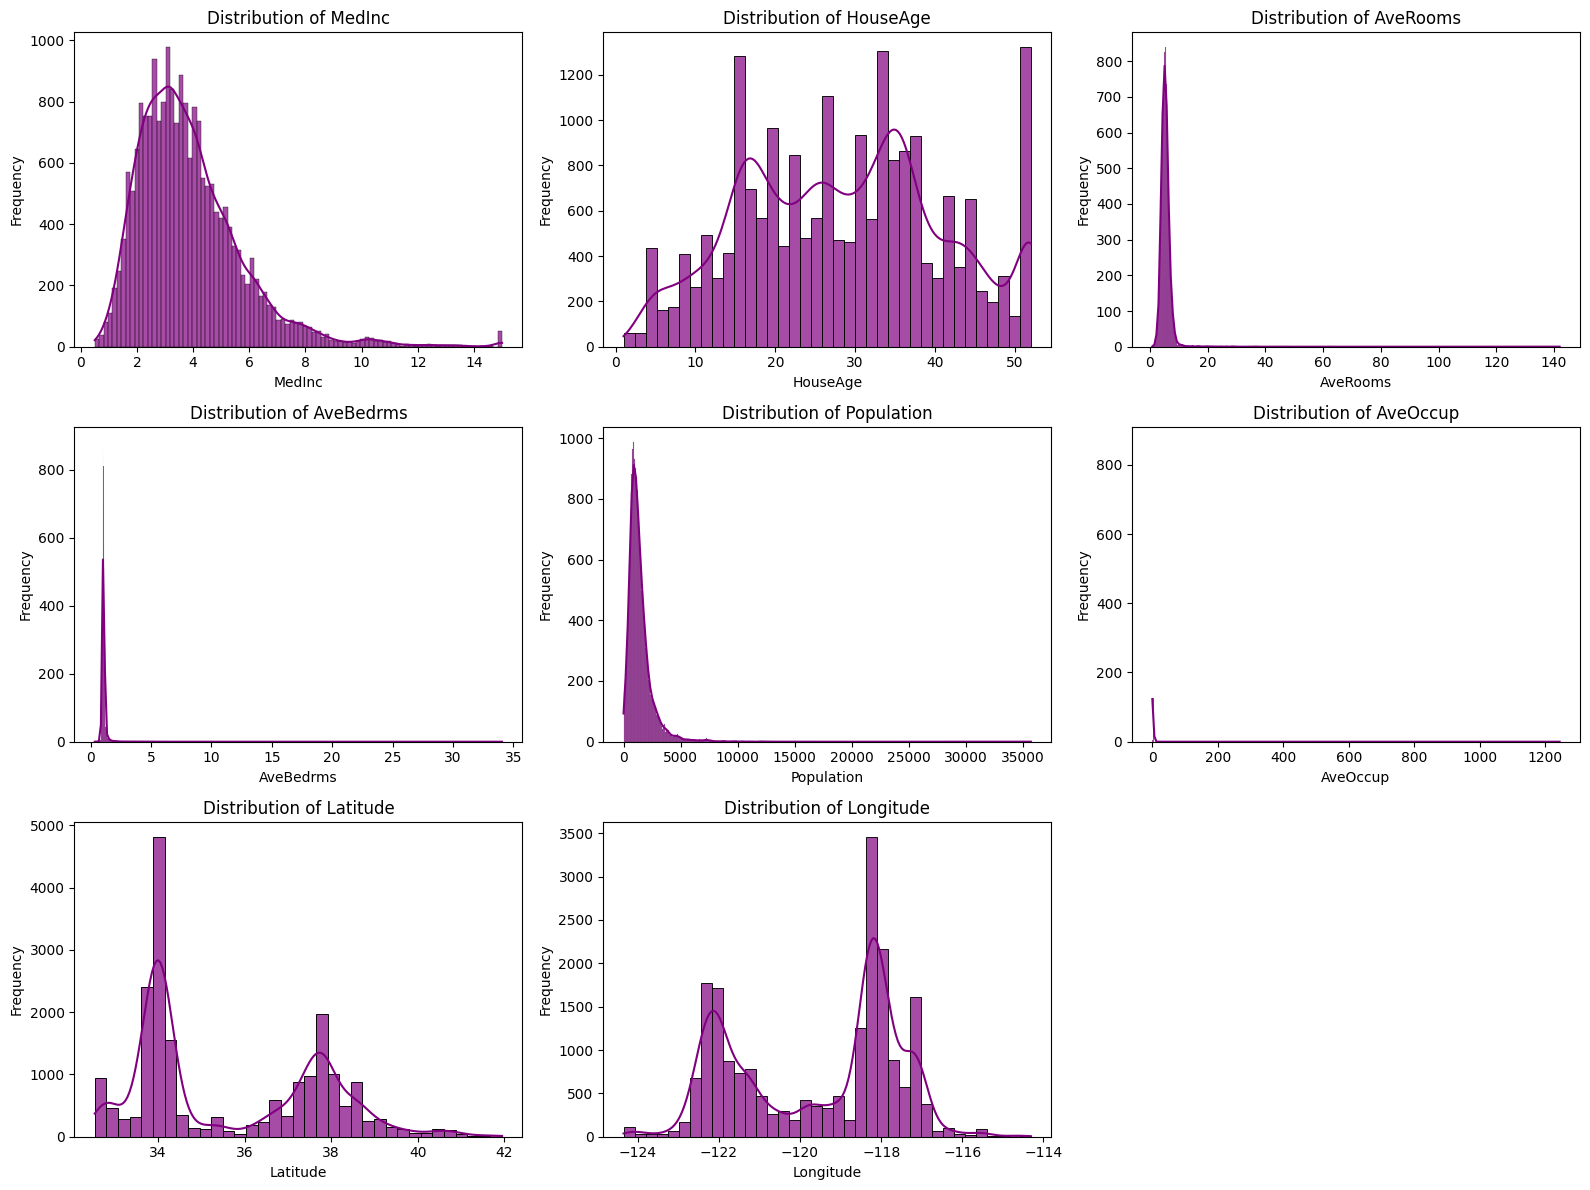

In [8]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


plt.figure(figsize=(16, 12))


for i, feature in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.histplot(df[feature], kde=True, color='purple', edgecolor='black', alpha=0.7)
    plt.title(f"Distribution of {feature}", fontsize=12, color='black')
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

* **b) Scatterplot**

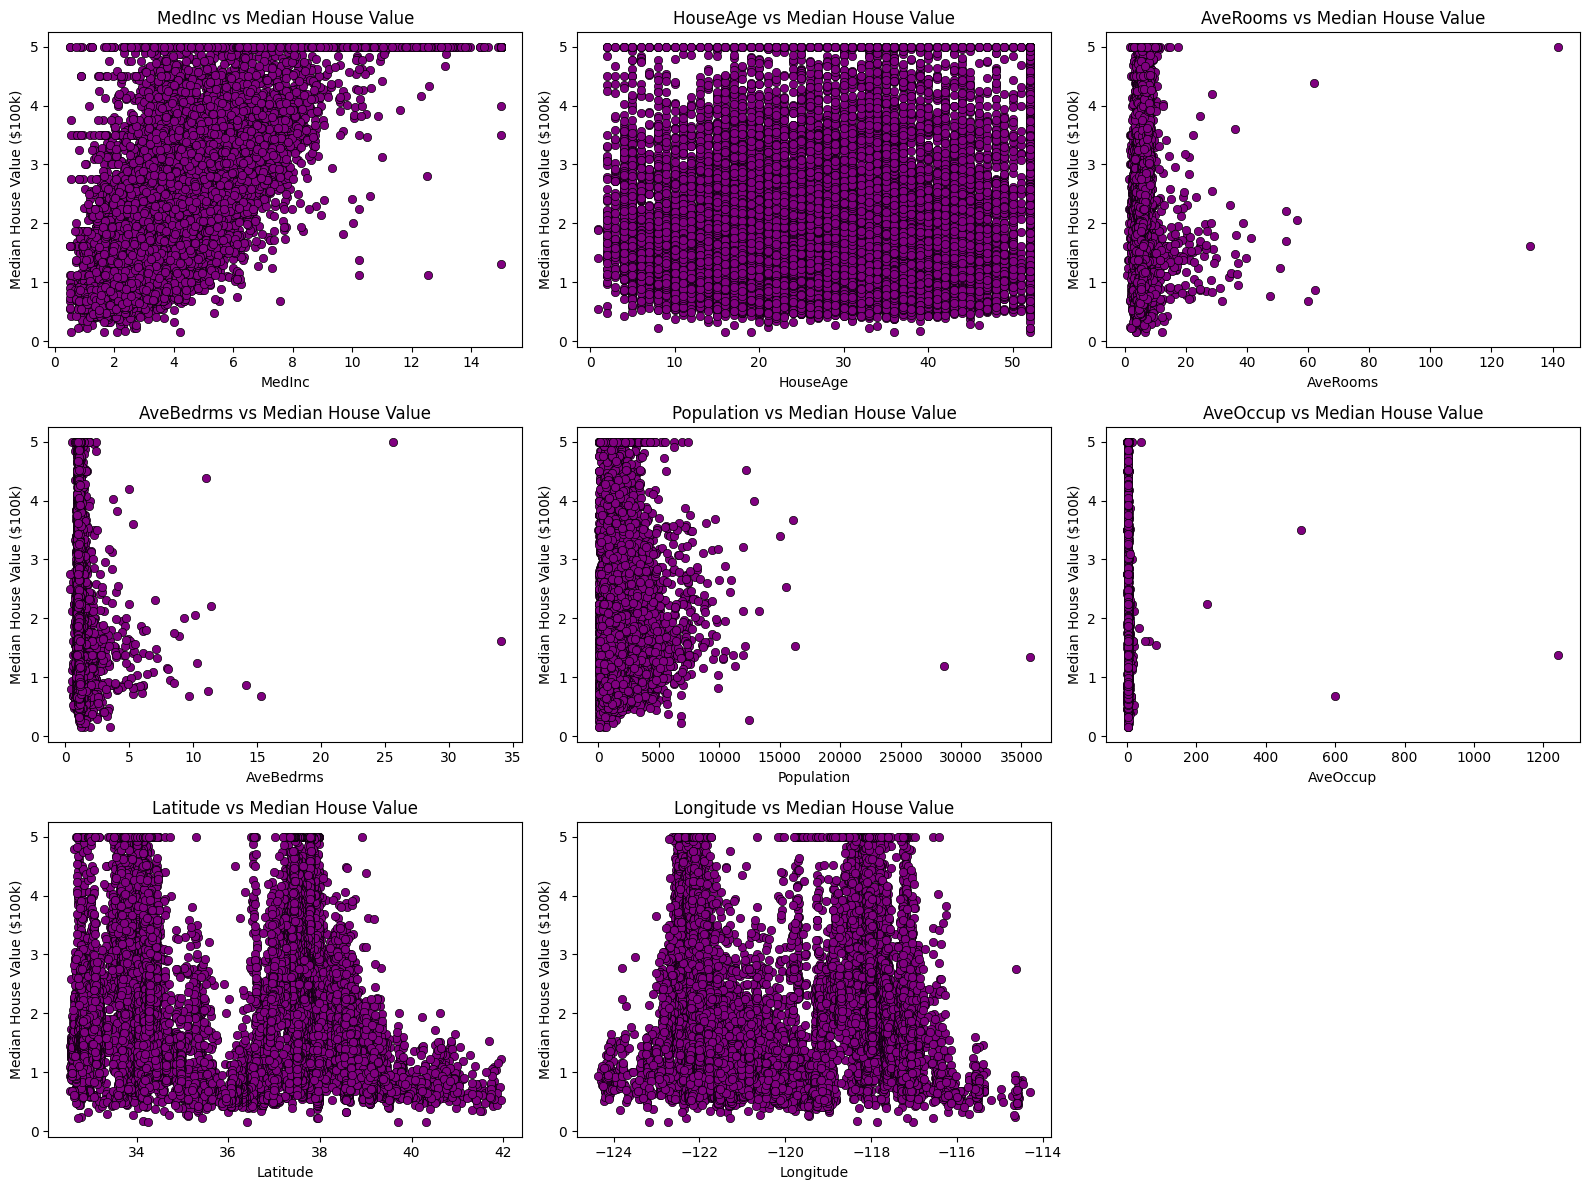

In [9]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


plt.figure(figsize=(16,12))


for i, feature in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(data=df, x=feature, y='MedHouseVal', color='purple', edgecolor='black')
    plt.title(f"{feature} vs Median House Value", fontsize=12, color='black')
    plt.xlabel(feature)
    plt.ylabel("Median House Value ($100k)")

plt.tight_layout()
plt.show()

* **c) boxplots**

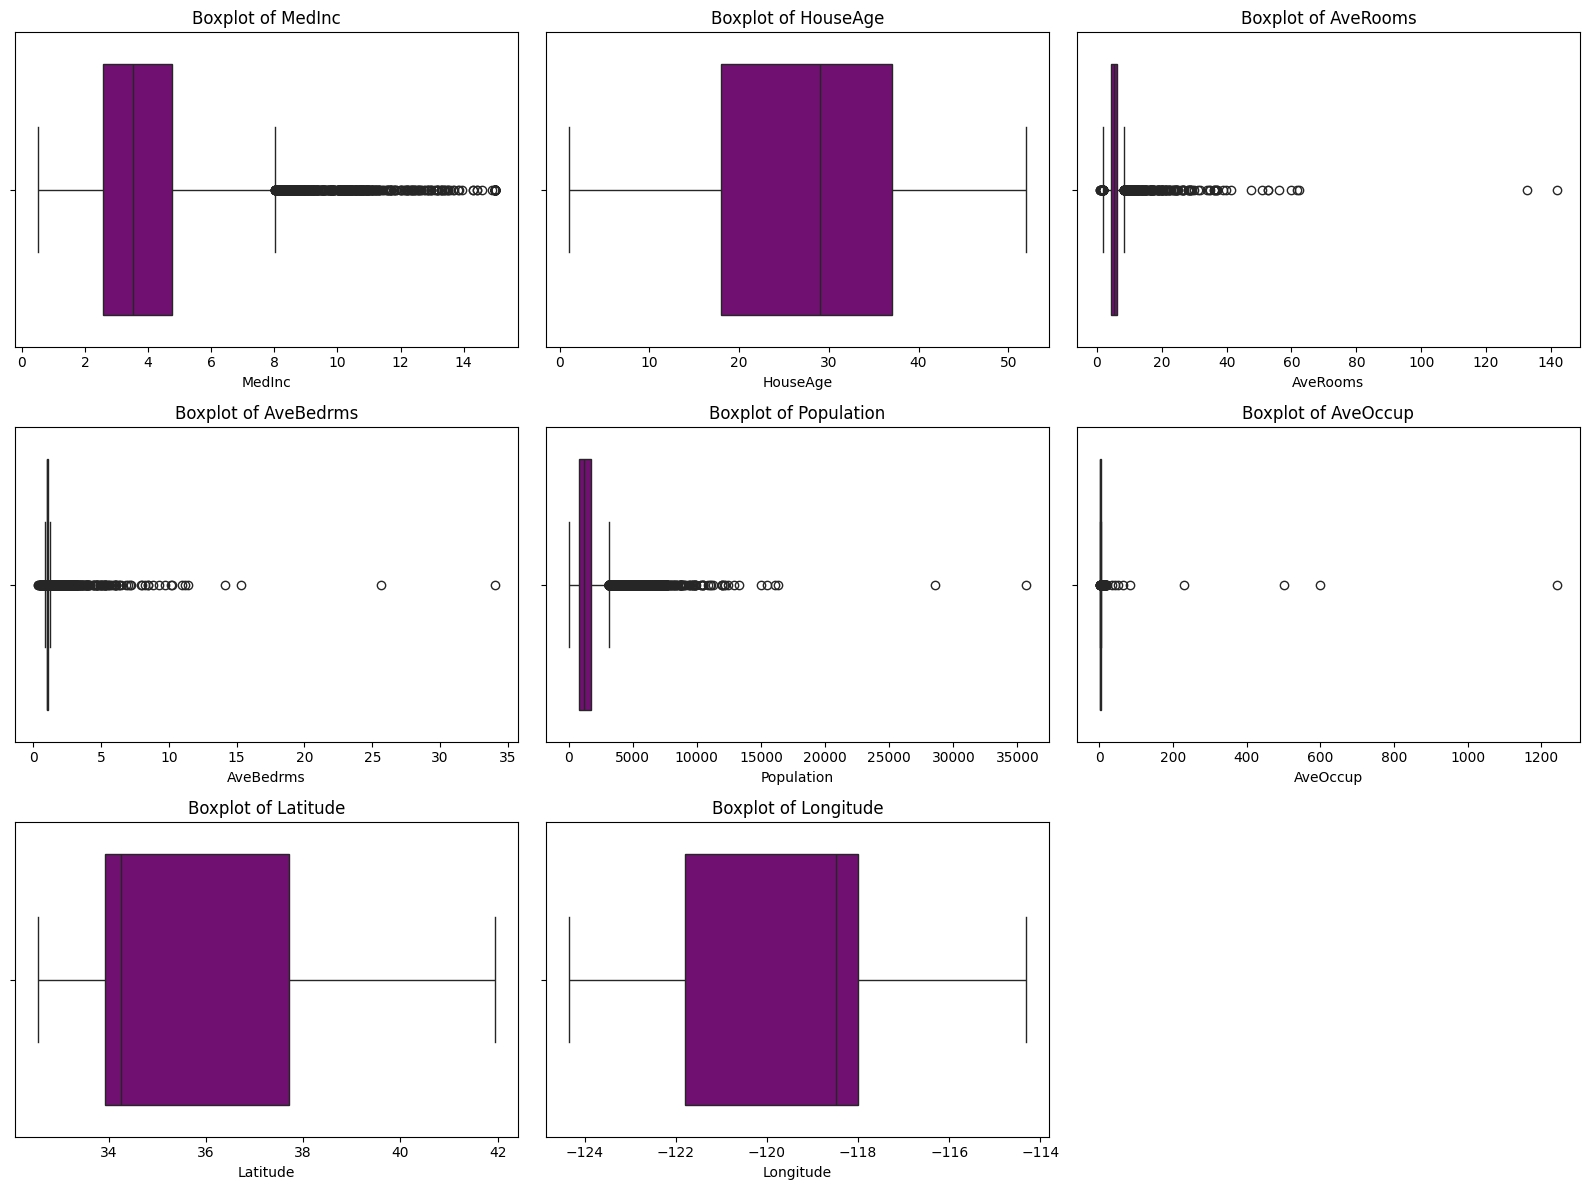

In [10]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

plt.figure(figsize=(16,12))

for i, feature in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[feature], color='purple')
    plt.title(f"Boxplot of {feature}", fontsize=12, color='black')
plt.tight_layout()
plt.show()

* **Provide a brief interpretation of your findings (e.g., which features seem most correlated withhouse value?).**

# 🔎 EDA – Key Insights

### **1️⃣ Key Correlations with House Value**
- **MedHouseVal & MedInc (0.69)** → Higher median income increases house prices  
- **AveRooms & AveBedrms** → Strong correlation (0.85), moderate effect on house value  
- **Population & AveOccup** → Skewed distribution with outliers, weak effect on price  
- **HouseAge** → Minimal effect  
- **Latitude & Longitude** → Low direct effect, but show geographic clusters  

### **2️⃣ Distribution & Outliers**
- Significant outliers in **Population** and **AveOccup**  
- **MedInc** slightly right-skewed, **HouseAge** roughly uniform  
- Outliers should be considered before modeling

> 💡 **Takeaway:** The most important predictor is **MedInc**, followed by house features like **rooms and bedrooms**, while other features have lower impact

<div class="alert alert-danger" role="alert"> 
🔎 2. Data Preprocessing (10%)

* **Split the data into training (80%) and testing (20%) sets. Use a fixed random state for reproducibility.**

In [11]:
X = df.drop('MedHouseVal', axis=1)
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25


In [12]:
Y = df['MedHouseVal']
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [13]:
print(f"skewness of Population is: {df['Population'].skew()}")
print(f"skewness of AveOccup is: {df['AveOccup'].skew()}")
print(f"skewness of AveRooms is: {df['AveRooms'].skew()}")
print(f"skewness of AveBedrms is: {df['AveBedrms'].skew()}")

skewness of Population is: 4.93585822672712
skewness of AveOccup is: 97.63956096369479
skewness of AveRooms is: 20.697868956710646
skewness of AveBedrms is: 31.316956246782663


In [14]:
# Transform skewed features
skewed_features = ['Population', 'AveOccup', 'AveRooms', 'AveBedrms']

# Apply log1p to reduce skewness
X[skewed_features] = X[skewed_features].apply(lambda x: np.log1p(x))

for feature in skewed_features:
    print(f"Skewness of {feature} after log-transform is: {X[feature].skew():.4f}")

Skewness of Population after log-transform is: -1.0441
Skewness of AveOccup after log-transform is: 3.8797
Skewness of AveRooms after log-transform is: 1.3908
Skewness of AveBedrms after log-transform is: 8.9888


In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=101)

In [16]:
print(f"shape of X_train is : {X_train.shape}")
print(f"shape of X_test is : {X_test.shape}")
print(f"shape of Y_train is : {Y_train.shape}")
print(f"shape of Y_test is : {Y_test.shape}")

shape of X_train is : (16512, 8)
shape of X_test is : (4128, 8)
shape of Y_train is : (16512,)
shape of Y_test is : (4128,)


In [17]:
# Handle Outliers with Capping (Winsorization) AFTER split

for feature in skewed_features:
    Q1 = X_train[feature].quantile(0.25)
    Q3 = X_train[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[feature] = np.clip(X_train[feature], lower_bound, upper_bound)
    X_test[feature] = np.clip(X_test[feature], lower_bound, upper_bound)


* **Standardize the features using StandardScaler. Important: Fit the scaler on the training set only, then transform both training and testing sets.**

In [18]:
scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("Feature scaling completed.")

Feature scaling completed.


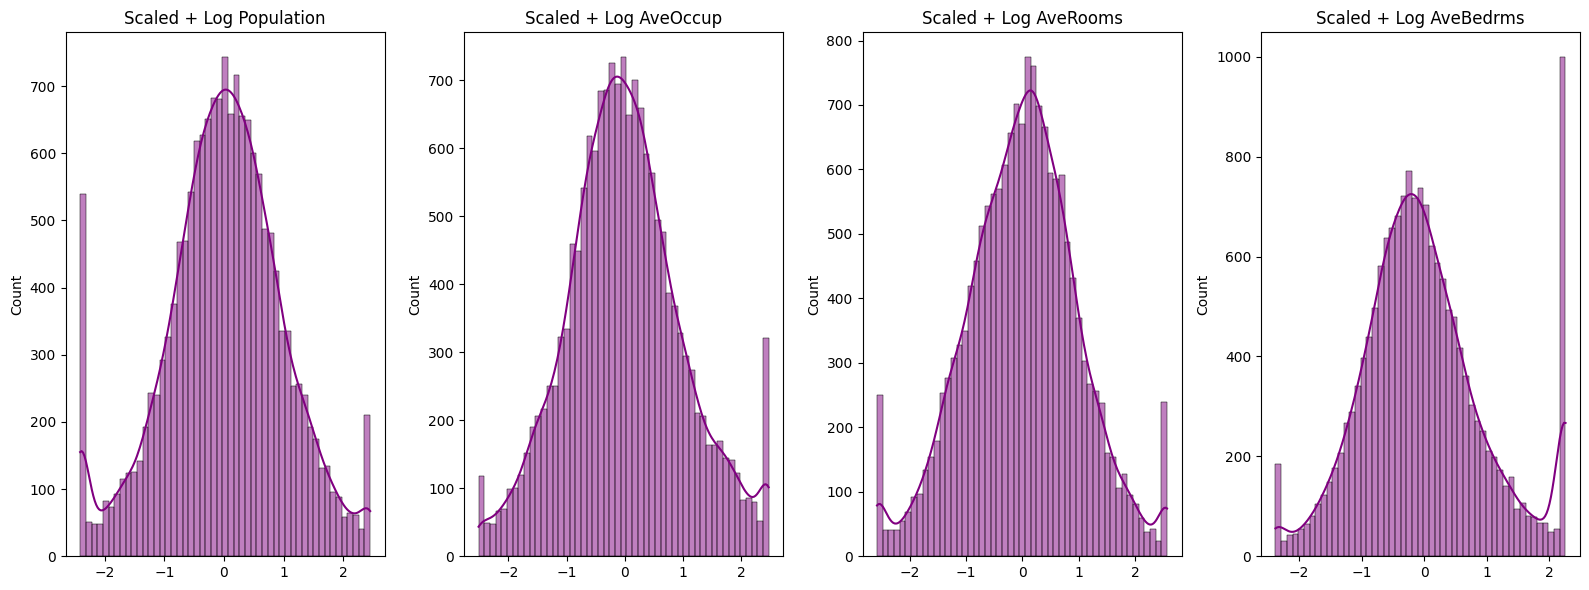

In [21]:
plt.figure(figsize=(16,6))
for i, feature in enumerate(skewed_features):
    plt.subplot(1, len(skewed_features), i+1)
    sns.histplot(X_train_scaled[:, X_train.columns.get_loc(feature)], kde=True, color='purple')
    plt.title(f"Scaled + Log {feature}")
plt.tight_layout()
plt.show()

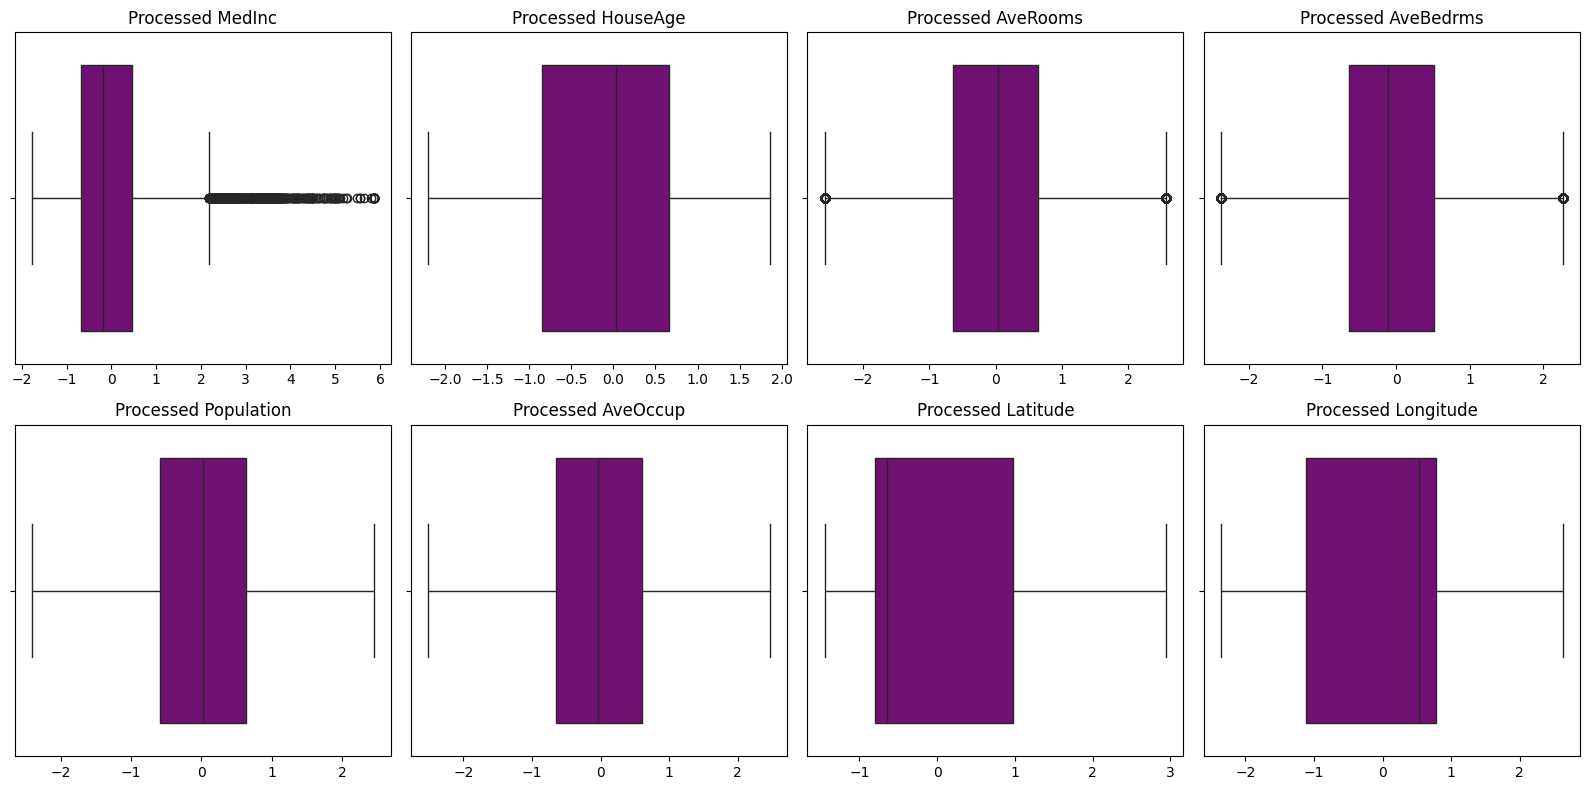

In [22]:
plt.figure(figsize=(16,8))
for i, feature in enumerate(features):
    plt.subplot(2, 4, i+1)
    idx = X_train.columns.get_loc(feature)
    sns.boxplot(x=X_train_scaled[:, idx], color='purple', showfliers=True)
    plt.title(f"Processed {feature}", fontsize=12)
plt.tight_layout()
plt.show()

* **Explain why scaling is necessary when using regularized linear models.**

# ⚖️ Feature Scaling – Importance in Regularized Linear Models

### **1️⃣ Regularization Penalty**
- **Ridge (L2)** and **Lasso (L1)** penalize the **magnitude of coefficients**.  
- Features with larger numerical ranges naturally produce larger coefficients → higher penalty.  
- Without scaling, the model may **bias towards small-range features** and underweight important large-range features.

### **2️⃣ Unequal Feature Scales**
- Example:  
  - Feature A in `[0, 1]` → small coefficient → small penalty  
  - Feature B in `[0, 10000]` → large coefficient → large penalty  
- Direct comparison of penalties becomes unfair, hurting model performance.

### **3️⃣ Standardization Fixes This**
- Subtract mean and divide by standard deviation → all features **mean=0, std=1**.  
- Regularization now penalizes all features **fairly**, allowing the model to learn appropriate coefficients.

> 💡 **Takeaway:** Scaling is essential for regularized models because it ensures **all features are treated equally**, preventing bias caused by different numerical ranges.

<div class="alert alert-danger" role="alert"> 
🔎 3. Baseline: Ordinary Least Squares (OLS) Linear Regression (15%)

* **Train a standard linear regression model (LinearRegression from sklearn.linear_model) on the standardized training data.**

In [23]:
ols_model = LinearRegression()
ols_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
ols_model.fit(X_train_scaled, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
print(f"theta is : {ols_model.coef_}")
print("-----------------------------------------------\n-----------------------------------------------")
print(f"theta0 is : {ols_model.intercept_}")

theta is : [ 0.80349546  0.14472959 -0.09689629  0.12256205  0.04359888 -0.28946538
 -0.88887719 -0.81094537]
-----------------------------------------------
-----------------------------------------------
theta0 is : 2.0660510895106543


In [26]:
y_pred = ols_model.predict(X_test_scaled)
y_pred

array([3.1457529 , 5.45548583, 1.13191933, ..., 2.19080847, 2.26866871,
       3.36007914], shape=(4128,))

In [27]:
Y_test

16086    4.06200
8816     5.00001
7175     1.22900
16714    2.09100
14491    5.00001
          ...   
5817     2.60500
3127     0.68500
15957    2.46200
843      2.54400
1659     3.29400
Name: MedHouseVal, Length: 4128, dtype: float64

* **Evaluate the model on the test**

In [28]:
MSE = metrics.mean_squared_error(Y_test, y_pred)

MAE = metrics.mean_absolute_error(Y_test, y_pred)

# RMSE = np.sqrt(MSE)
RMSE = metrics.root_mean_squared_error(Y_test, y_pred)

R2_ = metrics.r2_score(Y_test, y_pred)

In [29]:
Eval_df = pd.DataFrame({'metrics': ['MSE', 'MAE', 'RMSE', 'R2'], 
                        'Value': [MSE, MAE, RMSE, R2_]})
Eval_df

,metrics,Value
0,MSE,0.468183
1,MAE,0.497012
2,RMSE,0.684239
3,R2,0.653678


* **Display the learned coefficients for each feature and comment on their magnitudes and signs (if interpretable).**

In [30]:
coeff_df = pd.DataFrame({
    'Feature': df.columns.drop('MedHouseVal'),
    'Coefficient': ols_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

coeff_df

,Feature,Coefficient
6,Latitude,-0.888877
7,Longitude,-0.810945
0,MedInc,0.803495
5,AveOccup,-0.289465
1,HouseAge,0.144730
3,AveBedrms,0.122562
2,AveRooms,-0.096896
4,Population,0.043599


# 📊 OLS Linear Regression

### **1️⃣ Key Observations**
- **Magnitude:**  
  - `MedInc` has the largest absolute coefficient → strongest impact on house value  
  - `AveRooms` AveRooms has a small negative coefficient in this fitted model, so it should not be described as a positive contributor  
  - `Longitude` and `Latitude` has negative effect  

- **Sign:**  
  - Positive → increase in feature increases house value  
  - Negative → increase in feature decreases house value  

> 💡 **Takeaway:** The coefficients reflect **feature importance** and **direction of influence**, providing insight into which factors drive house prices in the dataset.

<div class="alert alert-danger" role="alert"> 
🔎 4. Ridge Regression (L2 Regularization) (20%)

* **Use RidgeCV (Ridge regression with built-in cross-validation) to automatically select the
best regularization strength α from a reasonable range (e.g., alphas = np.logspace(-3,
3, 50)).**

In [31]:
# Define alpha range
alphas = np.logspace(-1, 1, 50)

print(f"Number of alpha values: {len(alphas)}")
print(f"Smallest alpha: {alphas.min()}")
print(f"Largest alpha: {alphas.max()}")

Number of alpha values: 50
Smallest alpha: 0.1
Largest alpha: 10.0


In [32]:
# RidgeCV model with 5-fold cross-validation

Ridge_cv = RidgeCV(
    alphas=alphas,
    scoring='neg_mean_squared_error',
    cv=5
)

In [33]:
Ridge_cv.fit(X_train_scaled, Y_train)

best_alpha_ridge = Ridge_cv.alpha_

print(f"Best alpha selected by RidgeCV is: {best_alpha_ridge:.6f}")

Best alpha selected by RidgeCV is: 1.264855


* **Train the model on the standardized training data and evaluate on the test set (MSE, R2).**

In [34]:
# Train final Ridge model using best alpha

Ridge_model = Ridge(alpha=best_alpha_ridge)
Ridge_model.fit(X_train_scaled, Y_train)

,alpha,np.float64(1.2648552168552958)
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [35]:
y_pred_ridge = Ridge_model.predict(X_test_scaled)

In [36]:
# Evaluate Ridge model

MSE_Ridge = metrics.mean_squared_error(Y_test, y_pred_ridge)
MAE_Ridge = metrics.mean_absolute_error(Y_test, y_pred_ridge)
RMSE_Ridge = metrics.root_mean_squared_error(Y_test, y_pred_ridge)

R2_Ridge = metrics.r2_score(Y_test, y_pred_ridge)

ridge_results = pd.DataFrame({
    "Model": ["Ridge Regression"],
    "Best Alpha": [best_alpha_ridge],
    "Test MSE": [MSE_Ridge],
    "Test MAE": [MAE_Ridge],
    "Test RMSE": [RMSE_Ridge],
    "Test R²": [R2_Ridge]
})

ridge_results

,Model,Best Alpha,Test MSE,Test MAE,Test RMSE,Test R²
0,Ridge Regression,1.264855,0.468181,0.496995,0.684237,0.653681


In [37]:
# Compute CV MSE for each alpha manually

kf = KFold(n_splits=5, shuffle=True, random_state=42)

Ridge_CV_MSE = []
Ridge_CV_std = []

for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    
    scores = cross_val_score(
        ridge_temp,
        X_train_scaled,
        Y_train,
        scoring='neg_mean_squared_error',
        cv=kf
    )
    
    mse_scores = -scores
    Ridge_CV_MSE.append(mse_scores.mean())
    Ridge_CV_std.append(mse_scores.std())

Ridge_CV_df = pd.DataFrame({
    "alpha": alphas,
    "mean_cv_mse": Ridge_CV_MSE,
    "std_cv_mse": Ridge_CV_std
})

Ridge_CV_df.head()

,alpha,mean_cv_mse,std_cv_mse
0,0.100000,0.433385,0.00771
1,0.109854,0.433385,0.00771
2,0.120679,0.433385,0.00771
3,0.132571,0.433385,0.00771
4,0.145635,0.433385,0.00771


* **Plot the cross-validation mean squared error as a function of α to illustrate the effect of regularization strength.**

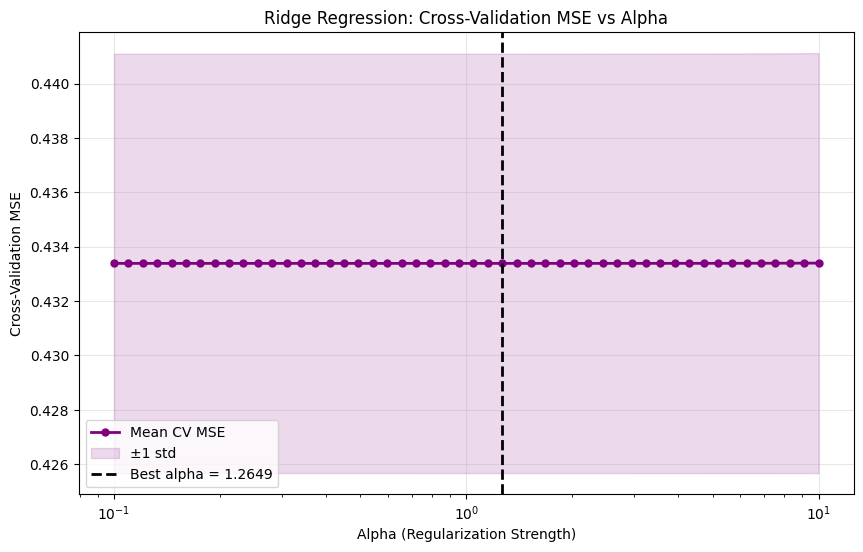

In [38]:
# Plot CV MSE versus alpha

plt.figure(figsize=(10, 6))

plt.plot(
    Ridge_CV_df["alpha"],
    Ridge_CV_df["mean_cv_mse"],
    marker='o',
    color='purple',
    linewidth=2,
    markersize=5,
    label='Mean CV MSE'
)

plt.fill_between(
    Ridge_CV_df["alpha"],
    Ridge_CV_df["mean_cv_mse"] - Ridge_CV_df["std_cv_mse"],
    Ridge_CV_df["mean_cv_mse"] + Ridge_CV_df["std_cv_mse"],
    color='purple',
    alpha=0.15,
    label='±1 std'
)

plt.axvline(
    best_alpha_ridge,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Best alpha = {best_alpha_ridge:.4f}'
)

plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Cross-Validation MSE")
plt.title("Ridge Regression: Cross-Validation MSE vs Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* **Compare the Ridge coefficients with the OLS coefficients. How does L2 penalty shrink the coefficients? Does it completely zero out any features?**

In [39]:
# Compare OLS and Ridge coefficients

feature_names = df.drop("MedHouseVal", axis=1).columns

Ridge_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "OLS Coefficient": ols_model.coef_,
    "Ridge Coefficient": Ridge_model.coef_
})

Ridge_coefficients["OLS |Coefficient|"] = Ridge_coefficients["OLS Coefficient"].abs()
Ridge_coefficients["Ridge |Coefficient|"] = Ridge_coefficients["Ridge Coefficient"].abs()

Ridge_coefficients["Shrinkage Amount"] = (
    Ridge_coefficients["OLS |Coefficient|"] - Ridge_coefficients["Ridge |Coefficient|"]
)

Ridge_coefficients["Shrinkage Percentage"] = (
    Ridge_coefficients["Shrinkage Amount"] / Ridge_coefficients["OLS |Coefficient|"]
) * 100

ridge_coefficients = Ridge_coefficients.sort_values(
    by="Ridge |Coefficient|",
    ascending=False
)

ridge_coefficients

,Feature,OLS Coefficient,Ridge Coefficient,OLS |Coefficient|,Ridge |Coefficient|,Shrinkage Amount,Shrinkage Percentage
6,Latitude,-0.888877,-0.887820,0.888877,0.887820,0.001058,0.118980
7,Longitude,-0.810945,-0.809907,0.810945,0.809907,0.001039,0.128097
0,MedInc,0.803495,0.803600,0.803495,0.803600,-0.000104,-0.012975
5,AveOccup,-0.289465,-0.289460,0.289465,0.289460,0.000006,0.001984
1,HouseAge,0.144730,0.144817,0.144730,0.144817,-0.000087,-0.060109
3,AveBedrms,0.122562,0.122526,0.122562,0.122526,0.000036,0.029262
2,AveRooms,-0.096896,-0.096994,0.096896,0.096994,-0.000097,-0.100451
4,Population,0.043599,0.043638,0.043599,0.043638,-0.000039,-0.090456


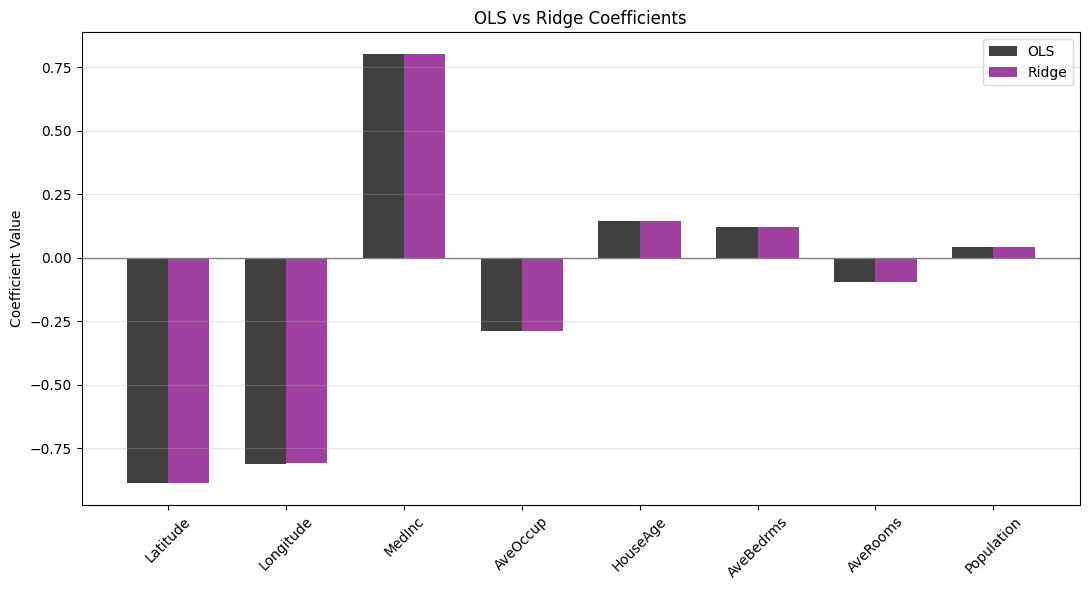

In [40]:
# Coefficient comparison plot

plt.figure(figsize=(11, 6))

x = np.arange(len(ridge_coefficients["Feature"]))
width = 0.35

plt.bar(
    x - width/2,
    ridge_coefficients["OLS Coefficient"],
    width,
    label="OLS",
    color="black",
    alpha=0.75
)

plt.bar(
    x + width/2,
    ridge_coefficients["Ridge Coefficient"],
    width,
    label="Ridge",
    color="purple",
    alpha=0.75
)

plt.axhline(0, color="gray", linewidth=1)
plt.xticks(x, ridge_coefficients["Feature"], rotation=45)
plt.ylabel("Coefficient Value")
plt.title("OLS vs Ridge Coefficients")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Ridge Regression

### **Key Observations**

- **Very small change compared to OLS:**  
  Ridge coefficients are almost the same as the OLS coefficients. This means that, in this dataset, Ridge did not noticeably change the model behavior  

- **Why the change is small:**  
  - The selected alpha is relatively moderate: **α = 1.2649**  
  - The features were already standardized, so the penalty was applied fairly across all variables  
  - The model does not seem to suffer from strong coefficient instability, so Ridge does not need to shrink the coefficients aggressively  

- **Coefficient shrinkage:**  
  Ridge slightly shrinks the coefficient magnitudes, but the effect is very small  
  Important features such as `MedInc`, `Latitude`, and `Longitude` remain the dominant predictors, similar to OLS  

- **No feature elimination:**  
  Ridge uses an L2 penalty, so it reduces coefficient size but does not force coefficients to become exactly zero  
  Therefore, all features remain in the model  

- **Model performance:**  
  The test performance is very close to OLS, with MSE ≈ **0.468** and R² ≈ **0.654**  
  This suggests that Ridge provides slightly more stable coefficients, but does not substantially improve prediction accuracy in this case  

> 💡 **Takeaway:** Ridge regression behaves very similarly to OLS in this project. The selected regularization strength is not large enough to create major coefficient changes, and the data does not require strong shrinkage. Therefore, Ridge mainly adds a small amount of stability while preserving the same feature importance pattern as OLS.

<div class="alert alert-danger" role="alert"> 
🔎 5. Lasso Regression (L1 Regularization) (20%)

* **Use LassoCV to select the best α (e.g., using 5-fold cross-validation and a suitable range of alphas). Note that Lasso may require a smaller α range; consider np.logspace(-4, 0, 50).**

In [41]:
# Lasso usually requires smaller alpha values

alphas_lasso = np.logspace(-4, 0, 50)

print(f"Number of alpha values: {len(alphas_lasso)}")
print(f"Smallest alpha: {alphas_lasso.min():.4f}")
print(f"Largest alpha: {alphas_lasso.max():.4f}")

Number of alpha values: 50
Smallest alpha: 0.0001
Largest alpha: 1.0000


In [42]:
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, Y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+00])
,fit_intercept,True
,precompute,'auto'
,max_iter,10000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [43]:
best_alpha_lasso = lasso_cv.alpha_
print(f"Best alpha selected by LassoCV is: {best_alpha_lasso:.6f}")

Best alpha selected by LassoCV is: 0.000100


In [44]:
lasso_model = Lasso(alpha=best_alpha_lasso)
lasso_model.fit(X_train_scaled, Y_train)

,alpha,np.float64(0.0001)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


* **Train the Lasso model on the standardized training data and evaluate on the test set (MSE, R2).**

In [45]:
# Evaluate lasso model

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_MSE = metrics.mean_squared_error(Y_test, y_pred_lasso)
lasso_MAE = metrics.mean_absolute_error(Y_test, y_pred_lasso)
lasso_RMSE = metrics.root_mean_squared_error(Y_test, y_pred_lasso)

lasso_R2 = metrics.r2_score(Y_test, y_pred_lasso)

lasso_results = pd.DataFrame({
    "Model": ["lasso Regression"],
    "Best Alpha": [best_alpha_lasso],
    "Test MSE": [lasso_MSE],
    "Test MAE": [lasso_MAE],
    "Test RMSE": [lasso_RMSE],
    "Test R²": [lasso_R2]
})

lasso_results

,Model,Best Alpha,Test MSE,Test MAE,Test RMSE,Test R²
0,lasso Regression,0.0001,0.468176,0.496986,0.684234,0.653684


* **Plot the cross-validation MSE versus α.**

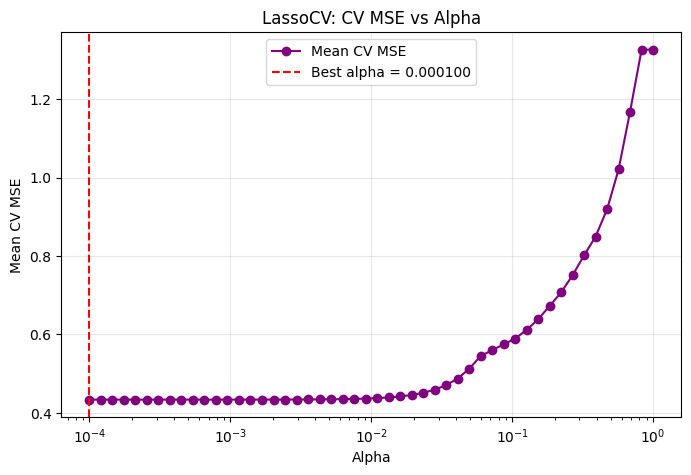

In [46]:
mean_cv_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(lasso_cv.alphas_, mean_cv_mse, marker='o', color='purple', label='Mean CV MSE')
plt.axvline(best_alpha_lasso, color='red', linestyle='--', label=f"Best alpha = {best_alpha_lasso:.6f}")
plt.xlabel("Alpha")
plt.ylabel("Mean CV MSE")
plt.title("LassoCV: CV MSE vs Alpha")
plt.legend()
plt.grid(True, alpha=0.3)

In [47]:
lasso_coefs = pd.Series(lasso_model.coef_, index=X_train.columns)

# Display all coefficients
lasso_coefs_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso_coefs.values,
    'Selected (Non-zero)': lasso_coefs != 0
}).sort_values(by='Coefficient', key=abs, ascending=False)

lasso_coefs_df

,Feature,Coefficient,Selected (Non-zero)
Latitude,Latitude,-0.887535,True
Longitude,Longitude,-0.809602,True
MedInc,MedInc,0.803425,True
AveOccup,AveOccup,-0.289391,True
HouseAge,HouseAge,0.144722,True
AveBedrms,AveBedrms,0.122338,True
AveRooms,AveRooms,-0.096810,True
Population,Population,0.043520,True


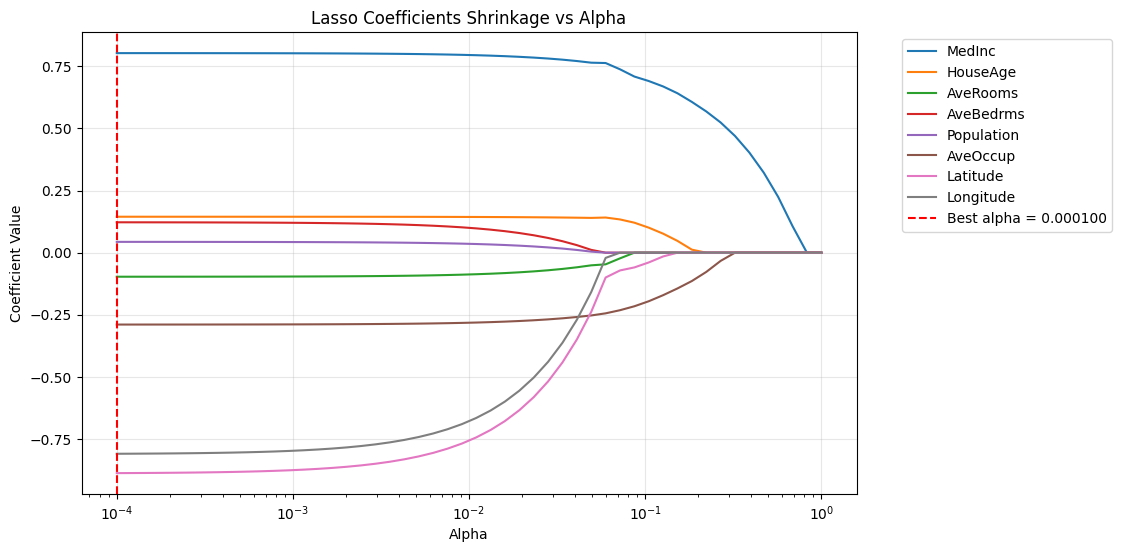

In [48]:
alphas = lasso_cv.alphas_
coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, Y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)  # shape: (n_alphas, n_features)

plt.figure(figsize=(10,6))
for i, feature in enumerate(X_train.columns):
    plt.semilogx(alphas, coefs[:, i], label=feature)

plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Best alpha = {lasso_cv.alpha_:.6f}')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficients Shrinkage vs Alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

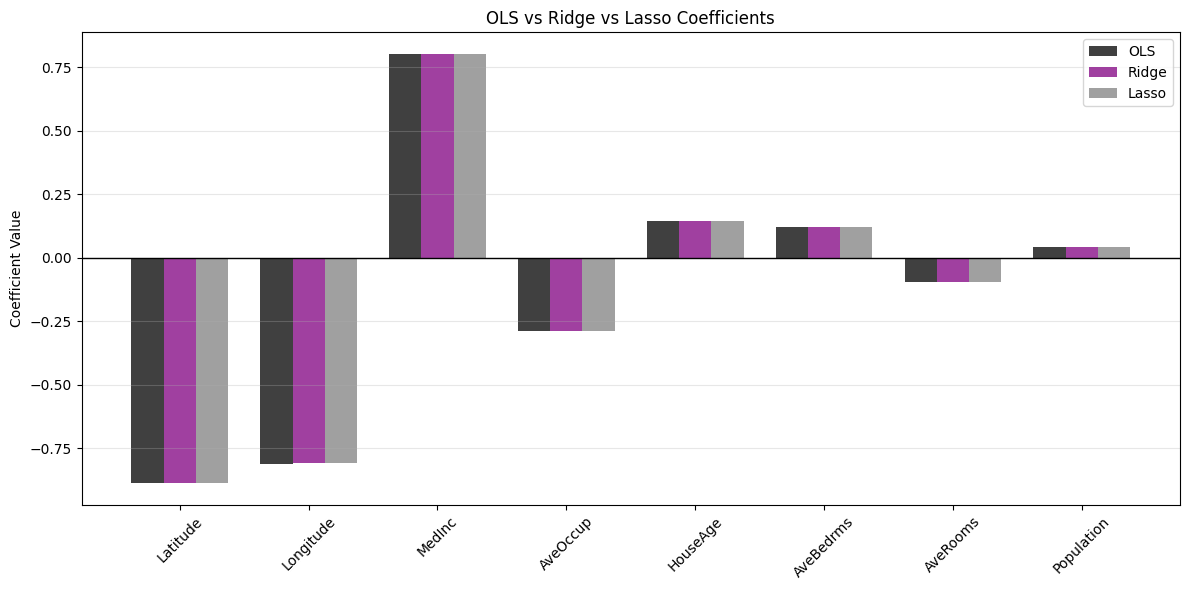

In [49]:
# Compare OLS, Ridge, and Lasso coefficients

coefficients_comparison = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS": ols_model.coef_,
    "Ridge": Ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coefficients_comparison = coefficients_comparison.set_index("Feature")

# Sort features by absolute OLS coefficient for better readability
coefficients_comparison = coefficients_comparison.loc[
    coefficients_comparison["OLS"].abs().sort_values(ascending=False).index
]

plt.figure(figsize=(12, 6))

x = np.arange(len(coefficients_comparison.index))
width = 0.25

plt.bar(
    x - width,
    coefficients_comparison["OLS"],
    width,
    label="OLS",
    color="black",
    alpha=0.75
)

plt.bar(
    x,
    coefficients_comparison["Ridge"],
    width,
    label="Ridge",
    color="purple",
    alpha=0.75
)

plt.bar(
    x + width,
    coefficients_comparison["Lasso"],
    width,
    label="Lasso",
    color="gray",
    alpha=0.75
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, coefficients_comparison.index, rotation=45)
plt.ylabel("Coefficient Value")
plt.title("OLS vs Ridge vs Lasso Coefficients")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Lasso Regression

### **Key Observations**
- **Alpha selection:**  
  - Best alpha from 5-fold CV: **0.0001**  
  - Small alpha explains why almost all coefficients remain non-zero  
  - Cross-validation MSE is stable at this alpha → model is robust  

- **Coefficient behavior:**  
  - Unlike Ridge, Lasso can shrink coefficients to zero, but here all features remain active due to small alpha  
  - Most influential features: `MedInc`, `Latitude`, `Longitude`  
  - Minor features slightly reduced but not eliminated  

- **Test performance:**  
  - MSE ≈ 0.468, RMSE ≈ 0.684, R² ≈ 0.654  
  - Similar to Ridge → regularization effect is small at this alpha, but stability and interpretability are preserved  

- **Visualization insights:**  
  - CV MSE vs alpha plot shows that for α < 0.0001, MSE slightly increases → optimal alpha balances fit and sparsity  
  - Coefficient shrinkage plot confirms all coefficients are non-zero  
  - Bar plot highlights non-zero coefficients in purple  

> 💡 **Takeaway:** Lasso regression with small alpha behaves very similarly to OLS and Ridge in this dataset. While capable of feature selection, the chosen alpha preserves all features, stabilizes coefficients slightly, and maintains feature importance and interpretability.

<div class="alert alert-danger" role="alert"> 
🔎 6. Comparative Analysis and Discussion (25%)

* **a. Performance Comparison**

In [50]:
def evaluate_train_test(model, X_train, y_train, X_test, y_test, model_name, alpha=None):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Model": model_name,
        "Alpha": alpha,
        "Train MSE": metrics.mean_squared_error(y_train, y_train_pred),
        "Test MSE": metrics.mean_squared_error(y_test, y_test_pred),
        "Train R²": metrics.r2_score(y_train, y_train_pred),
        "Test R²": metrics.r2_score(y_test, y_test_pred)
    }

comparison_required = pd.DataFrame([
    evaluate_train_test(ols_model, X_train_scaled, Y_train, X_test_scaled, Y_test, "OLS"),
    evaluate_train_test(Ridge_model, X_train_scaled, Y_train, X_test_scaled, Y_test, "Ridge", best_alpha_ridge),
    evaluate_train_test(lasso_model, X_train_scaled, Y_train, X_test_scaled, Y_test, "Lasso", best_alpha_lasso)
])

comparison_required.style.format({
    "Alpha": "{:.7f}",
    "Train MSE": "{:.7f}",
    "Test MSE": "{:.7f}",
    "Train R²": "{:.7f}",
    "Test R²": "{:.7f}"
}).highlight_min(
    subset=["Test MSE"], color="darkred"
).highlight_max(
    subset=["Test R²"], color="darkgreen"
)

,Model,Alpha,Train MSE,Test MSE,Train R²,Test R²
0,OLS,nan,0.4328593,0.4681834,0.6736678,0.6536785
1,Ridge,1.2648552,0.4328595,0.4681805,0.6736677,0.6536806
2,Lasso,0.0001000,0.4328597,0.4681762,0.6736676,0.6536838


# 📊 Performance Comparison

### **Key Observations**
- **Overall performance:**  
  - OLS, Ridge, and Lasso show almost identical test performance  
  - Test MSE values are all close to **0.468**  
  - Test R² values are all close to **0.654**  

- **Best model:**  
  - Lasso has the lowest Test MSE: **0.468176**  
  - Lasso also has the highest Test R²: **0.653684**  
  - However, the difference from Ridge and OLS is extremely small  

- **Regularization effect:**  
  - Ridge and Lasso do not substantially improve prediction accuracy over OLS  
  - This suggests that regularization has only a limited effect on test performance in this experiment  

- **Generalization check:**  
  - Train MSE ≈ **0.433**, while Test MSE ≈ **0.468**  
  - The train-test gap is small, so there is no strong evidence of severe overfitting  

> 💡 **Takeaway:** Lasso performs best numerically, but the improvement is not practically substantial. Overall, OLS, Ridge, and Lasso have almost the same predictive performance on the test set.

* **b. Overfitting Evidence**

In [51]:
overfitting_analysis = comparison_required.copy()

overfitting_analysis["MSE Gap (Test - Train)"] = (
    overfitting_analysis["Test MSE"] - overfitting_analysis["Train MSE"]
)

overfitting_analysis["R² Gap (Train - Test)"] = (
    overfitting_analysis["Train R²"] - overfitting_analysis["Test R²"]
)

# Display the table
overfitting_analysis.style.highlight_max(
    subset=["MSE Gap (Test - Train)"], color="darkred"
).highlight_min(
    subset=["MSE Gap (Test - Train)"], color="darkgreen"
)

,Model,Alpha,Train MSE,Test MSE,Train R²,Test R²,MSE Gap (Test - Train),R² Gap (Train - Test)
0,OLS,nan,0.432859,0.468183,0.673668,0.653678,0.035324,0.019989
1,Ridge,1.264855,0.432859,0.468181,0.673668,0.653681,0.035321,0.019987
2,Lasso,0.000100,0.432860,0.468176,0.673668,0.653684,0.035317,0.019984


# 📊 Overfitting Evidence

### **Key Observations**
- **Train-test gap:**  
  - Train MSE ≈ **0.433**, Test MSE ≈ **0.468**  
  - Train R² ≈ **0.674**, Test R² ≈ **0.654**  
  - The gap is small for all three models  

- **OLS vs Ridge/Lasso:**  
  - OLS does not have a larger error gap than Ridge or Lasso  
  - Ridge and Lasso do not noticeably reduce test error compared with OLS  

- **Interpretation:**  
  - No strong evidence of severe overfitting is observed  
  - The main limitation is likely the **linear structure** of the models, not excessive variance  

> 💡 **Takeaway:** OLS, Ridge, and Lasso generalize almost similarly. Regularization does not substantially reduce overfitting in this experiment.

* **c. Coefficient Interpretation**

In [52]:
coef_comparison = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_model.coef_,
    "Ridge": Ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_magnitude = coef_comparison.copy()
coef_magnitude[["OLS", "Ridge", "Lasso"]] = coef_magnitude[["OLS", "Ridge", "Lasso"]].abs()

coef_magnitude = coef_magnitude.sort_values(by="OLS", ascending=False)

coef_magnitude

,Feature,OLS,Ridge,Lasso
6,Latitude,0.888877,0.887820,0.887535
7,Longitude,0.810945,0.809907,0.809602
0,MedInc,0.803495,0.803600,0.803425
5,AveOccup,0.289465,0.289460,0.289391
1,HouseAge,0.144730,0.144817,0.144722
3,AveBedrms,0.122562,0.122526,0.122338
2,AveRooms,0.096896,0.096994,0.096810
4,Population,0.043599,0.043638,0.043520


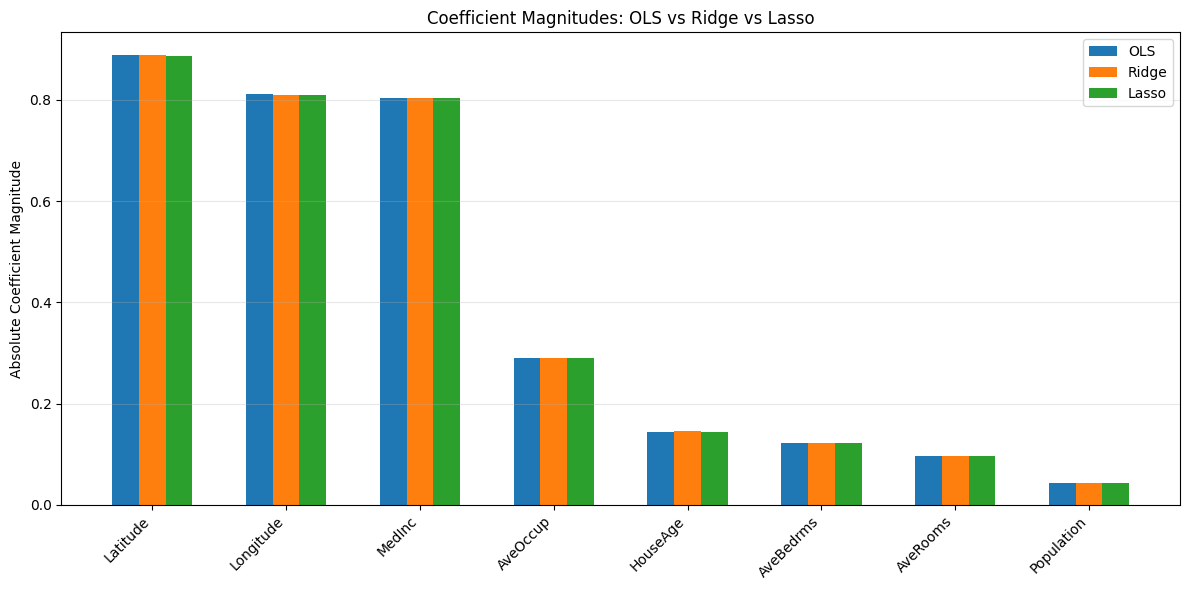

In [53]:
plt.figure(figsize=(12, 6))

x = np.arange(len(coef_magnitude["Feature"]))
width = 0.2

plt.bar(x - width, coef_magnitude["OLS"], width, label="OLS")
plt.bar(x, coef_magnitude["Ridge"], width, label="Ridge")
plt.bar(x + width, coef_magnitude["Lasso"], width, label="Lasso")

plt.xticks(x, coef_magnitude["Feature"], rotation=45, ha="right")
plt.ylabel("Absolute Coefficient Magnitude")
plt.title("Coefficient Magnitudes: OLS vs Ridge vs Lasso")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# 📊 Coefficient Interpretation

### **Key Observations**
- **Main features:**  
  - The largest coefficients belong to `Latitude`, `Longitude`, and `MedInc`  
  - `MedInc` has a strong positive effect  
  - `Latitude` and `Longitude` show important spatial effects  

- **Ridge effect:**  
  - Ridge coefficients are very close to OLS  
  - L2 penalty slightly shrinks/stabilizes coefficients  
  - No coefficient becomes zero  

- **Lasso effect:**  
  - Lasso can set coefficients to zero  
  - Here, all coefficients remain non-zero because alpha is very small  
  - Therefore, no clear sparsity is created  

> 💡 **Takeaway:** OLS, Ridge, and Lasso show very similar coefficient patterns. Regularization only slightly changes the coefficients, and the most influential features are `MedInc`, `Latitude`, and `Longitude`.

* **d. Feature Selection Insight**

In [54]:
lasso_feature_insight = pd.DataFrame({
    "Feature": feature_names,
    "Lasso Coefficient": lasso_model.coef_,
    "|Coefficient|": np.abs(lasso_model.coef_),
    "Selected by Lasso": np.abs(lasso_model.coef_) > 1e-6
})

target_col = "MedHouseVal"

eda_corr = df.corr(numeric_only=True)[target_col].drop(target_col)

lasso_feature_insight["EDA Correlation with Target"] = (
    lasso_feature_insight["Feature"].map(eda_corr)
)

lasso_feature_insight = lasso_feature_insight.sort_values(
    by="|Coefficient|",
    ascending=False
).reset_index(drop=True)

lasso_feature_insight

,Feature,Lasso Coefficient,|Coefficient|,Selected by Lasso,EDA Correlation with Target
0,Latitude,-0.887535,0.887535,True,-0.144160
1,Longitude,-0.809602,0.809602,True,-0.045967
2,MedInc,0.803425,0.803425,True,0.688075
3,AveOccup,-0.289391,0.289391,True,-0.023737
4,HouseAge,0.144722,0.144722,True,0.105623
5,AveBedrms,0.122338,0.122338,True,-0.046701
6,AveRooms,-0.096810,0.096810,True,0.151948
7,Population,0.043520,0.043520,True,-0.024650


# 📊 Feature Selection Insight

### **Key Observations**
- **Most important features:**  
  - Lasso gives the largest coefficient magnitudes to `Latitude`, `Longitude`, and `MedInc`  
  - `MedInc` also has the strongest correlation with the target in EDA  

- **Least important features:**  
  - `Population` and `AveRooms` have the smallest coefficient magnitudes  
  - Their contribution is weaker compared with income and location-related features  

- **Feature selection:**  
  - All Lasso coefficients remain non-zero  
  - Because the selected alpha is very small, Lasso does not eliminate any feature  

- **EDA alignment:**  
  - `MedInc` aligns well with the correlation heatmap  
  - `Latitude` and `Longitude` reflect spatial effects that simple correlation may not fully show  

> 💡 **Takeaway:** Lasso highlights `MedInc`, `Latitude`, and `Longitude` as the most important features, but it does not perform strong feature selection because all coefficients remain active.

* **e. Limitations and Assumptions**

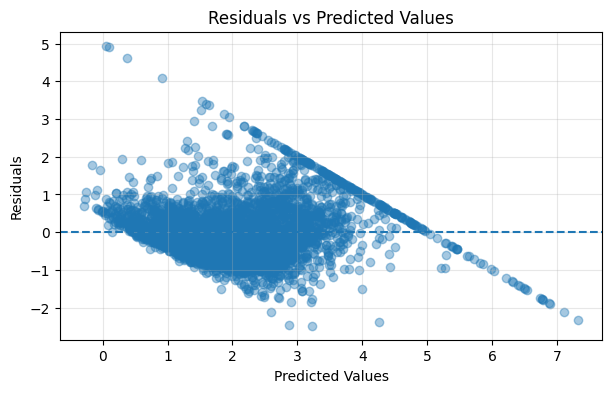

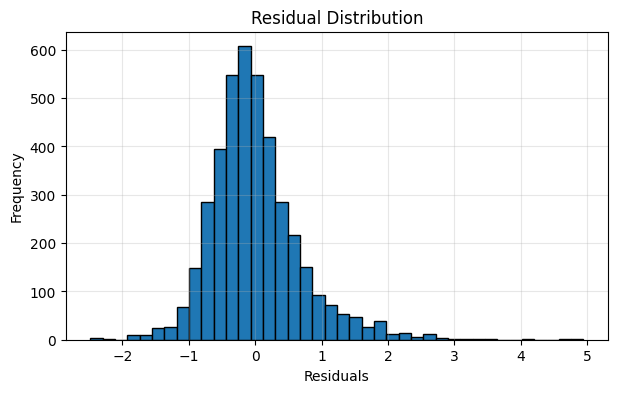

In [55]:
y_pred_ols = ols_model.predict(X_test_scaled)
residuals = Y_test - y_pred_ols

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_ols, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

# 📊 Limitations and Assumptions

### **Key Observations**
- Linear regression assumes linearity, independence, constant error variance, and normal residuals  
- Residual plots suggest that these assumptions are only partially satisfied  
- Housing prices are affected by nonlinear spatial and economic patterns  
- Ridge and Lasso control coefficient size, but they do not solve nonlinearity  

> 💡 **Takeaway:** The main limitation is likely the linear structure of the models, not severe overfitting.

<div class="alert alert-danger" role="alert"> 
🔎 Final Extension: Polynomial Models + Final Comparison

Original number of features: 8
Number of polynomial features: 44
Polynomial feature scaling completed.


C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.574e+01, tolerance: 1.752e+00
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.414e+01, tolerance: 1.752e+00
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\7_Laptop\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the feat

,Model,Best Alpha,Test MSE,Test MAE,Test RMSE,Test R²
0,OLS Linear Regression,NaN,0.468183,0.497012,0.684239,0.653678
1,Polynomial Linear Regression,NaN,0.388131,0.436809,0.623002,0.712894
2,Ridge Regression,1.264855,0.468181,0.496995,0.684237,0.653681
3,Lasso Regression,0.000100,0.468176,0.496986,0.684234,0.653684
4,Polynomial Ridge Regression,0.001000,0.388058,0.436830,0.622943,0.712948
5,Polynomial Lasso Regression,0.000001,0.390580,0.441245,0.624964,0.711083



Models sorted by lowest Test MSE:


,Model,Best Alpha,Test MSE,Test MAE,Test RMSE,Test R²
4,Polynomial Ridge Regression,0.001000,0.388058,0.436830,0.622943,0.712948
1,Polynomial Linear Regression,NaN,0.388131,0.436809,0.623002,0.712894
5,Polynomial Lasso Regression,0.000001,0.390580,0.441245,0.624964,0.711083
3,Lasso Regression,0.000100,0.468176,0.496986,0.684234,0.653684
2,Ridge Regression,1.264855,0.468181,0.496995,0.684237,0.653681
0,OLS Linear Regression,NaN,0.468183,0.497012,0.684239,0.653678


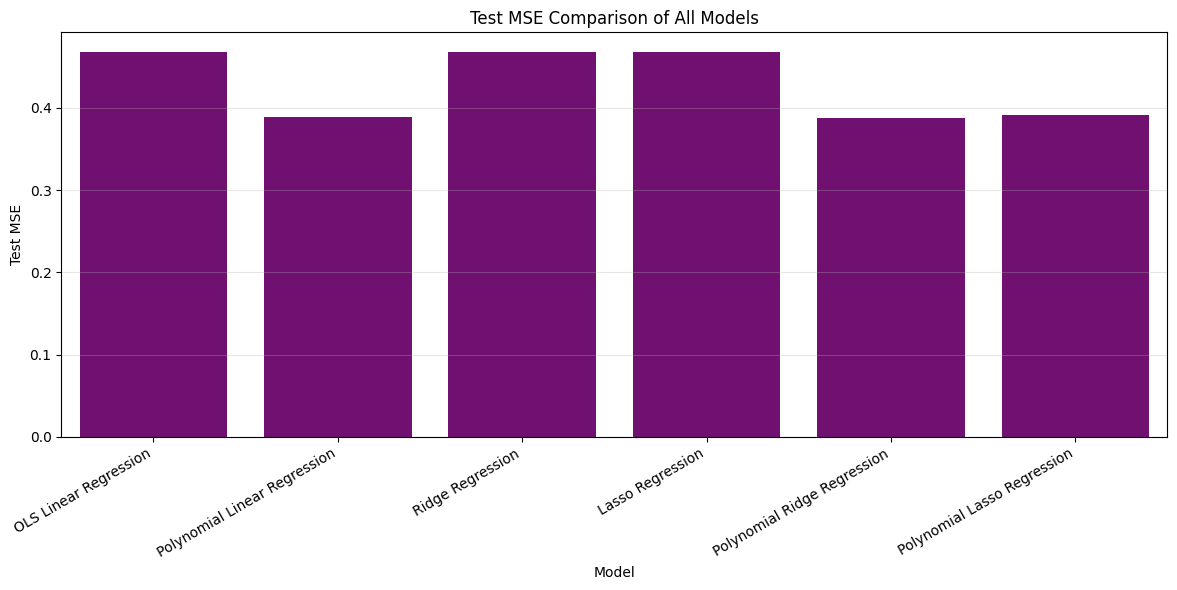

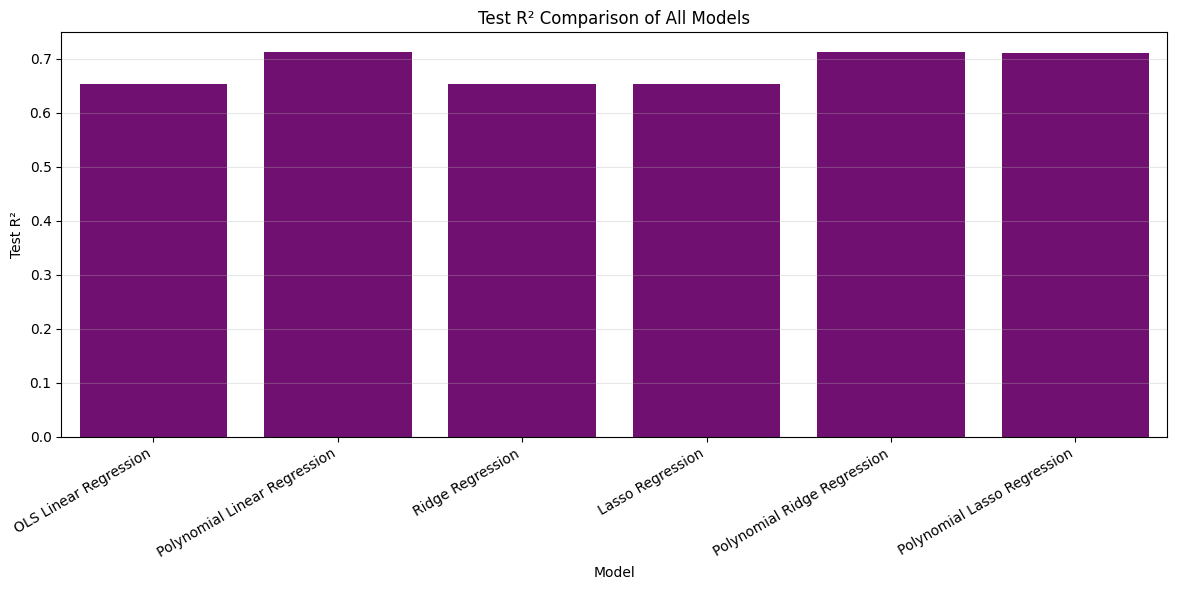

In [56]:
# Final Extension: Polynomial Models + Final Comparison
# Models:
# 1. OLS Linear Regression
# 2. Polynomial Linear Regression
# 3. Ridge Regression
# 4. Lasso Regression
# 5. Polynomial Ridge Regression
# 6. Polynomial Lasso Regression



# 1. Create Polynomial Features

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_feature_names = poly.get_feature_names_out(X_train.columns)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of polynomial features: {X_train_poly.shape[1]}")


# 2. Scale Polynomial Features

poly_scaler = StandardScaler()

X_train_poly_scaled = poly_scaler.fit_transform(X_train_poly)
X_test_poly_scaled = poly_scaler.transform(X_test_poly)

print("Polynomial feature scaling completed.")


# 3. Polynomial Linear Regression

poly_linear_model = LinearRegression()
poly_linear_model.fit(X_train_poly_scaled, Y_train)

y_pred_poly = poly_linear_model.predict(X_test_poly_scaled)

poly_MSE = metrics.mean_squared_error(Y_test, y_pred_poly)
poly_MAE = metrics.mean_absolute_error(Y_test, y_pred_poly)
poly_RMSE = metrics.root_mean_squared_error(Y_test, y_pred_poly)
poly_R2 = metrics.r2_score(Y_test, y_pred_poly)


# 4. Polynomial Ridge Regression

alphas_poly_ridge = np.logspace(-3, 3, 80)

poly_ridge_cv = RidgeCV(
    alphas=alphas_poly_ridge,
    scoring='neg_mean_squared_error',
    cv=5
)

poly_ridge_cv.fit(X_train_poly_scaled, Y_train)

best_alpha_poly_ridge = poly_ridge_cv.alpha_

y_pred_poly_ridge = poly_ridge_cv.predict(X_test_poly_scaled)

poly_ridge_MSE = metrics.mean_squared_error(Y_test, y_pred_poly_ridge)
poly_ridge_MAE = metrics.mean_absolute_error(Y_test, y_pred_poly_ridge)
poly_ridge_RMSE = metrics.root_mean_squared_error(Y_test, y_pred_poly_ridge)
poly_ridge_R2 = metrics.r2_score(Y_test, y_pred_poly_ridge)


# 5. Polynomial Lasso Regression

alphas_poly_lasso = np.logspace(-6, 0, 80)

poly_lasso_cv = LassoCV(
    alphas=alphas_poly_lasso,
    cv=5,
    random_state=42,
    max_iter=50000
)

poly_lasso_cv.fit(X_train_poly_scaled, Y_train)

best_alpha_poly_lasso = poly_lasso_cv.alpha_

y_pred_poly_lasso = poly_lasso_cv.predict(X_test_poly_scaled)

poly_lasso_MSE = metrics.mean_squared_error(Y_test, y_pred_poly_lasso)
poly_lasso_MAE = metrics.mean_absolute_error(Y_test, y_pred_poly_lasso)
poly_lasso_RMSE = metrics.root_mean_squared_error(Y_test, y_pred_poly_lasso)
poly_lasso_R2 = metrics.r2_score(Y_test, y_pred_poly_lasso)


# 6. Final Comparison Table

final_model_comparison = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Polynomial Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Polynomial Ridge Regression",
        "Polynomial Lasso Regression"
    ],
    "Best Alpha": [
        np.nan,
        np.nan,
        best_alpha_ridge,
        best_alpha_lasso,
        best_alpha_poly_ridge,
        best_alpha_poly_lasso
    ],
    "Test MSE": [
        MSE,
        poly_MSE,
        MSE_Ridge,
        lasso_MSE,
        poly_ridge_MSE,
        poly_lasso_MSE
    ],
    "Test MAE": [
        MAE,
        poly_MAE,
        MAE_Ridge,
        lasso_MAE,
        poly_ridge_MAE,
        poly_lasso_MAE
    ],
    "Test RMSE": [
        RMSE,
        poly_RMSE,
        RMSE_Ridge,
        lasso_RMSE,
        poly_ridge_RMSE,
        poly_lasso_RMSE
    ],
    "Test R²": [
        R2_,
        poly_R2,
        R2_Ridge,
        lasso_R2,
        poly_ridge_R2,
        poly_lasso_R2
    ]
})

display(final_model_comparison)

print("\nModels sorted by lowest Test MSE:")
display(final_model_comparison.sort_values(by="Test MSE", ascending=True))


# 7. Plot Test MSE Comparison

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_model_comparison,
    x="Model",
    y="Test MSE",
    color="purple"
)

plt.title("Test MSE Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("Test MSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# 8. Plot Test R² Comparison

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_model_comparison,
    x="Model",
    y="Test R²",
    color="purple"
)

plt.title("Test R² Comparison of All Models")
plt.xlabel("Model")
plt.ylabel("Test R²")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Final Model Comparison: Linear, Regularized, and Polynomial Models

### **1️⃣ Overall Performance**

The final comparison shows a clear difference between the original linear models and the polynomial-based models.

- `OLS`, `Ridge`, and `Lasso` have almost identical performance  
  - Test MSE ≈ **0.468**
  - Test R² ≈ **0.654**

- Polynomial-based models perform noticeably better  
  - `Polynomial Ridge Regression` gives the lowest Test MSE: **0.3881**
  - It also gives the highest Test R²: **0.7129**
  - `Polynomial Linear Regression` performs almost the same as Polynomial Ridge, with Test MSE ≈ **0.3881**
  - `Polynomial Lasso Regression` is slightly weaker than Polynomial Ridge, but still much better than the original linear models

This indicates that the original linear feature space was not able to capture all patterns in the data. Adding degree-2 polynomial and interaction terms improved the model’s ability to represent nonlinear relationships.

---

### **2️⃣ Linear Models: OLS, Ridge, and Lasso**

The three original linear models produce nearly the same results. Ridge and Lasso do not substantially improve over OLS.

- Ridge only applies a very small shrinkage effect  
- Lasso selects a very small alpha, so its behavior remains very close to OLS  
- None of the original linear models captures the nonlinear structure as well as the polynomial models  

This suggests that the main limitation is not overfitting in the original linear model, but rather the limited expressiveness of a purely linear relationship.

---

### **3️⃣ Polynomial Models**

Degree-2 polynomial features increased the feature space from the original 8 variables to a larger set of squared and interaction terms. This allowed the model to capture relationships such as:

- `MedInc × Longitude`
- `Latitude × Longitude`
- `HouseAge × Longitude`
- `Latitude²`
- `Longitude²`

The strong performance of the polynomial models suggests that housing prices are affected by nonlinear and interaction effects, especially those involving location-related variables such as `Latitude` and `Longitude`.

---

### **4️⃣ Best Model**

Based on the test metrics, the best-performing model is:

**Polynomial Ridge Regression**

It has:

- Lowest Test MSE: **0.3881**
- Lowest Test RMSE: **0.6229**
- Highest Test R²: **0.7129**

Polynomial Ridge slightly outperforms Polynomial Linear Regression. This is expected because Ridge regularization helps control the increased complexity introduced by polynomial features.

---

### **5️⃣ Polynomial Lasso Interpretation**

Polynomial Lasso also improves over the original linear models, but it performs slightly worse than Polynomial Ridge.

The selected alpha is very small, which means Lasso applies weak L1 regularization in this case. Therefore, the model does not strongly eliminate polynomial terms. Instead, it behaves closer to a lightly regularized polynomial model.
---

### **6️⃣ Important Note on Interpretability**

Although polynomial models improve predictive performance, they are harder to interpret than the original linear models.

In OLS, Ridge, and Lasso, each coefficient corresponds directly to one original feature.  
In polynomial models, coefficients correspond to transformed terms such as squared variables or feature interactions. Therefore, coefficient interpretation becomes less direct.

> 💡 **Takeaway:**  
> The original linear models are stable but limited. Ridge and Lasso do not significantly improve performance in the original feature space. Polynomial features substantially improve prediction accuracy, showing that the California housing dataset contains nonlinear and interaction effects. Among all models, Polynomial Ridge provides the best balance between predictive performance and regularization.